In [1]:
!pip install -q tensorflow==2.19.0
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q imageio tqdm

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.1 MB/s eta 0:00:00


In [2]:
import os, sys, numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from tqdm import tqdm
import random
#I will be using OpenAI CLIP library (image-text embedding model) and clip is used through pytorch
import clip
import torch

print("TF",tf.__version__)
device= "cuda" if torch.cuda.is_available() else "cpu"
model_clip,preprocess_clip=clip.load("ViT-B/32",device=device)


TF 2.19.0


100%|███████████████████████████████████████| 338M/338M [00:05<00:00, 68.3MiB/s]


In [6]:
# mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:

#setting up the base paths
BASE="/content/drive/MyDrive/Corneal_ulcer_model"
train_images = np.load(os.path.join(BASE, "train_images.npy"))
train_ulcer  = np.load(os.path.join(BASE, "train_ulcer.npy"))
val_images   = np.load(os.path.join(BASE, "val_images.npy"))
val_ulcer    = np.load(os.path.join(BASE, "val_ulcer.npy"))
test_images  = np.load(os.path.join(BASE, "test_images.npy"))
test_ulcer   = np.load(os.path.join(BASE, "test_ulcer.npy"))

#Ensuring shapes: shape standardisation : (batch_size, height, width, 1) + type casting
def ensure_mask_shape(m):
  if m.ndim==3:
    return np.expand_dims(m, -1)
  return m

train_ulcer = ensure_mask_shape(train_ulcer).astype(np.uint8)
val_ulcer   = ensure_mask_shape(val_ulcer).astype(np.uint8)
test_ulcer  = ensure_mask_shape(test_ulcer).astype(np.uint8)

print("Train images:", train_images.shape)
print("Train masks:", train_ulcer.shape)

Train images: (247, 256, 256, 3)
Train masks: (247, 256, 256, 1)


# for medical image segemntation:


*   slit lamp Input: an eye image (RGB)
*   Output: a pixel-level mask of a corneal ulcer

*   Key difficulties:

    1.   Ulcers can be small
    2.   Boundaries matter
    1.  Dataset size is limited
    2.   Strong class imbalance (lots of background, few ulcer pixels)
    Unet is architecture most compatibel with this.



In [14]:
#Metrics used for the model
def DiceCoef(y_true, y_pred, smooth=1e-6):
  y_true_f=tf.reshape(y_true, [-1])
  y_pred_f=tf.reshape(y_pred, [-1])
  intersection=tf.reduce_sum(y_true_f * y_pred_f)
  return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def IouCoef(y_true, y_pred, smooth=1e-6):
    y_true_f= tf.reshape(y_true, [-1])
    y_pred_f=tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

#Basic UNet builder
def BuildUnet(input_shape=(256,256,3), filters=32):
  inputs = keras.Input(shape=input_shape)
  #Encoder
  convs = []
  x = inputs
  for f in [filters, filters*2, filters*4, filters*8]:
    x =layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    x =layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    convs.append(x)
    x = layers.MaxPooling2D(2)(x)

  #Bottleneck
  x =layers.Conv2D(filters*16, 3, padding='same', activation='relu')(x)
  x= layers.Conv2D(filters*16, 3, padding='same', activation='relu')(x)

  #Decoder
  for i, f in enumerate([filters*8, filters*4, filters*2, filters]):
    x=layers.Conv2DTranspose(f, 2, strides=2, padding='same')(x)
    x= layers.Concatenate()([x, convs[-1-i]])
    x=  layers.Conv2D(f, 3, padding='same', activation='relu')(x)
    x =layers.Conv2D(f, 3, padding='same', activation='relu')(x)
  outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)
  return keras.Model(inputs, outputs)

unet = BuildUnet()
unet.compile(optimizer=keras.optimizers.Adam(1e-4),
             loss=keras.losses.BinaryCrossentropy(),
             metrics=[DiceCoef, IouCoef])
unet.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 256, 256,  │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 256, 256,  │      9,248 │ conv2d_19[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 128, 128,  │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 128, 128,  │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 128, 128,  │     36,928 │ conv2d_21[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 64, 64,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 64, 64,    │     73,856 │ max_pooling2d_5[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 64, 64,    │    147,584 │ conv2d_23[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 32, 32,    │          0 │ conv2d_24[0][0]   │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 32, 32,    │    295,168 │ max_pooling2d_6[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 32, 32,    │    590,080 │ conv2d_25[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 16, 16,    │          0 │ conv2d_26[0][0]   │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 16, 16,    │  1,180,160 │ max_pooling2d_7[… │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 16, 16,    │  2,359,808 │ conv2d_27[0][0]   │
│                     │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 32, 32,    │    524,544 │ conv2d_28[0][0]   │
│ (Conv2DTranspose)   │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_4       │ (None, 32, 32,    │          0 │ conv2d_transpose

 Total params: 7,760,097 (29.60 MB)

 Trainable params: 7,760,097 (29.60 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from  tensorflow.keras.preprocessing.image import ImageDataGenerator
image_args=dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=(0.8, 1.2),   # OK for images
    fill_mode="nearest"
)

mask_args=dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode="nearest"
    #no brightness_range for masks as it migth turn them grey therefore messing up the model
)

image_generated= ImageDataGenerator(**image_args)
mask_generated= ImageDataGenerator(**mask_args)

BATCH=8
def PairedGenerator(X,Y,batch_size=BATCH,seed=42):

  img_flow  = image_generated.flow(X, batch_size=batch_size, seed=seed, shuffle=True)
  mask_flow = mask_generated.flow(Y, batch_size=batch_size, seed=seed, shuffle=True)
  while True:
    xi = next(img_flow)
    yi = next(mask_flow)
    # Rebinarised masks to prevent grey edges from interpolation/augmentation
    yi = (yi > 0.5).astype(np.float32)

    yield xi, yi
TrainGen = PairedGenerator(train_images, train_ulcer, batch_size=BATCH, seed=42)

#Keeping validation clean to measure real performance
def ValGenerator(X, Y, batch_size=BATCH):

  n = len(X)
  i = 0
  while True:

    j = min(i + batch_size, n)
    xi = X[i:j]
    yi = Y[i:j].astype(np.float32)
    yi = (yi > 0.5).astype(np.float32)  # ensure binary
    yield xi, yi
    if j >= n:
      i = 0
    else:
      i = j

valGen = ValGenerator(val_images, val_ulcer, batch_size=BATCH)

#using ceil to nto drop leftovers
train_steps= max(1, int(np.ceil(len(train_images) / BATCH)))
val_steps= max(1, int(np.ceil(len(val_images) / BATCH)))

#Training
EPOCHS= 50
history= unet.fit(
    TrainGen,
    steps_per_epoch=train_steps,
    validation_data=valGen,
    validation_steps=val_steps,
    epochs=EPOCHS
)
unet.save(os.path.join(BASE, "UnetBaselineSynthetic1.keras"))
#this saves the trainign log of the model to analyse trainign behaviour
np.save(os.path.join(BASE,"HistoryUnetBaseline.npy"), history.history)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 24s 456ms/step - dice_coef: 0.0525 - iou_coef: 0.0271 - loss: 0.6839 - val_dice_coef: 1.7945e-05 - val_iou_coef: 8.9727e-06 - val_loss: 0.6467
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 9s 290ms/step - dice_coef: 0.0213 - iou_coef: 0.0109 - loss: 0.2294 - val_dice_coef: 1.3531e-06 - val_iou_coef: 6.7655e-07 - val_loss: 0.6206
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 203ms/step - dice_coef: 0.0222 - iou_coef: 0.0113 - loss: 0.1820 - val_dice_coef: 1.2224e-04 - val_iou_coef: 6.1124e-05 - val_loss: 0.3539
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 239ms/step - dice_coef: 0.0255 - iou_coef: 0.0129 - loss: 0.1385 - val_dice_coef: 0.0479 - val_iou_coef: 0.0246 - val_loss: 0.1407
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - dice_coef: 0.0623 - iou_coef: 0.0322 - loss: 0.1226 - val_dice_coef: 2.2911e-04 - val_iou_coef: 1.1460e-04 - val_loss: 0.5202
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 240ms/step - dice_coef: 0.0554 - iou_coef: 0.0286 - loss: 0.1045 -

In [22]:
TestPred=unet.predict(test_images)

#Converting probabilities to a binary mask using a threshold
testPred_bin=(TestPred>0.5).astype(np.float32)

#Compute metrics
def computeMetrics(y_true,y_pred):
  dices,ious= [],[]
  for a, b in zip(y_true, y_pred):
    a = tf.convert_to_tensor(a, dtype=tf.float32)
    b = tf.convert_to_tensor(b, dtype=tf.float32)
    dices.append(DiceCoef(a, b).numpy())
    ious.append(IouCoef(a, b).numpy())
  return np.mean(dices), np.mean(ious)

dice_test,iou_test = computeMetrics(test_ulcer,testPred_bin)
print("Test Dice IS :",dice_test, "Test IoU:", iou_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Test Dice IS : 1.5962199e-11 Test IoU: 1.5962199e-11


In [24]:
#Why SciPy?
#It's a standard tool for elastic deformation (commonly used in classic MNISTaugmentation and medical segmentation augmentation).
import scipy.ndimage as ndi

def elastic_transform(mask, alpha=20, sigma=4):
  shape = mask.shape
  dx= ndi.gaussian_filter((np.random.rand(*shape)* 2 - 1),sigma) *alpha
  dy= ndi.gaussian_filter((np.random.rand(*shape)* 2 - 1), sigma) *  alpha
  x,y = np.meshgrid(np.arange(shape[1]), np.arange(shape[0]))
  map_x = (x + dx).astype(np.float32)
  map_y  = (y + dy).astype(np.float32)
  return cv2.remap(mask.astype(np.float32), map_x,map_y,interpolation=cv2.INTER_NEAREST)

#created synthetic segmentation masks by taking each real training mask and generating 2 extra "perturbed" versions using:
        # random rotation + scale
        # elastic deformation
        # random dilation or erosion

def perturb_one(mask):

  #mask:(H,W,1) binary
  m = mask.squeeze().astype(np.uint8)
  # Small rotate/scale
  angle = random.uniform(-10, 10)
  scale = random.uniform(0.95, 1.05)
  M = cv2.getRotationMatrix2D((m.shape[1]//2, m.shape[0]//2), angle, scale)
  m2= cv2.warpAffine(m, M, (m.shape[1], m.shape[0]), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_REFLECT)
  #elastic
  m3= elastic_transform(m2, alpha=random.uniform(6,18), sigma=random.uniform(3,6))
  #morphological tweak
  if random.random() > 0.5:
    kernel= np.ones((3,3), np.uint8)
    m3 = cv2.dilate((m3>0.5).astype(np.uint8), kernel, iterations=1)
  else:
    kernel = np.ones((3,3), np.uint8)
    m3 = cv2.erode((m3>0.5).astype(np.uint8), kernel, iterations=1)
  return (m3>0.5).astype(np.uint8)

#Generating 2 perturbATIONs per training mask
new_masks =[]
for m in tqdm(train_ulcer):
    new_masks.append(m if m.ndim==3 else np.expand_dims(m, -1))
    for _ in range(2):
        pm =perturb_one(m)
        new_masks.append(np.expand_dims(pm, -1))
new_masks= np.array(new_masks)

print("Generated perturbed masks:",new_masks.shape)
np.save(os.path.join(BASE, "perturbed_masks.npy"),new_masks)


100%|██████████| 247/247 [00:04<00:00, 54.83it/s]


Generated perturbed masks: (741, 256, 256, 1)


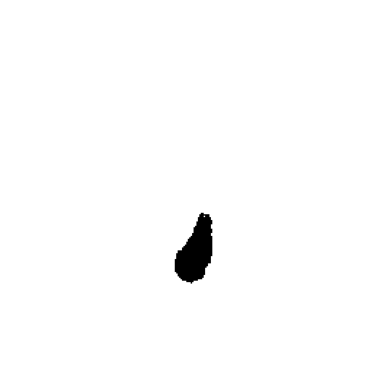

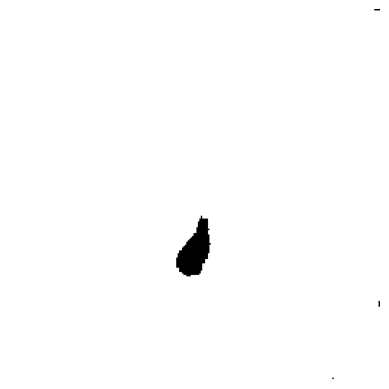

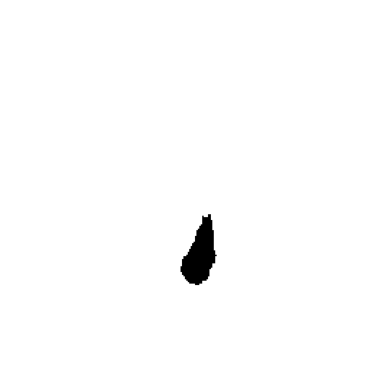

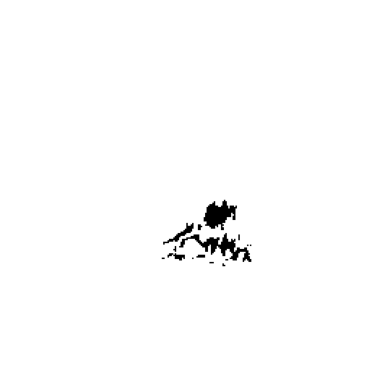

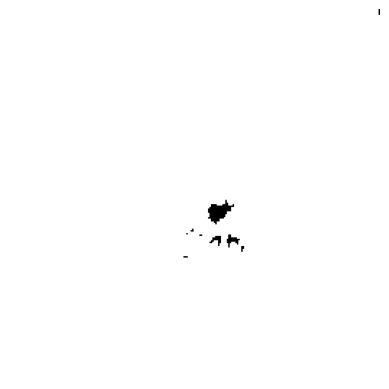

In [25]:
import matplotlib.pyplot as plt
for i in range(5):
    plt.imshow(new_masks[i].squeeze(), cmap='gray')
    plt.axis('off')
    plt.show()

In [26]:
!pip install git+https://github.com/tensorflow/examples.git

  Cloning https://github.com/tensorflow/examples.git to /tmp/pip-req-build-5he42qvz
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/examples.git /tmp/pip-req-build-5he42qvz
  Resolved https://github.com/tensorflow/examples.git to commit 79e40789448a066b645598c8642464d170abfc37
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-examples: filename=tensorflow_examples-0.1768389971.695873109670739525881551651508911927732665580599-py3-none-any.whl size=300309 sha256=3309b24db88c797106a03f04d95341f63b7e38c3ded0cf6d60333b4bb5b4cd72
  Stored in directory: /tmp/pip-ephem-wheel-cache-zg9o36ms/wheels/ab/17/30/d16d07e2c95286770a9ddcd6f41629ea92b998858c5ee235aa
Successfully built tensorflow-examples


I tried creating mask→image generator using pix2pix(a conditional GAN) then tried to use it to turn the perturbed masks into synthetic images so I can end up with synthetic (image,mask) pairs for segmentation training.

pipeline:


1.   Create more masks: perturb the real masks → perturbed_masks
2.   Train a generator to map mask → image using real pairs

1.   Use generator to create synthetic images from perturbed_masks

2.   end up with sunthetic pairs (synthetic_image, perturbed_mask)





In [28]:
from tensorflow_examples.models.pix2pix import pix2pix

# Prepare pairs:mask input(1chan)-> image target(3chan)
x_train_mask = train_ulcer.astype('float32')
y_train_img   = train_images.astype('float32')
x_train_mask_3ch= np.repeat(x_train_mask, 3, axis=-1)
# normalize to [-1,1]
x_train_mask = x_train_mask*2.0 - 1.0
y_train_img  = y_train_img*2.0 - 1.0

# small tf dataset
BUFFER=1000
BATCH=8
# This creates batches of:
    #input: mask (3-channel)
    # target: real image
    #So pix2pix learns: mask → realistic eye image.

trainingData = tf.data.Dataset.from_tensor_slices((x_train_mask_3ch,y_train_img)).shuffle(BUFFER).batch(BATCH)

#PixToPix generator and descriminiator
generator = pix2pix.unet_generator(output_channels=3, norm_type='batchnorm')
discriminator = pix2pix.discriminator(norm_type='batchnorm', target=True)

#Loss functions:
loss_object =tf.keras.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real, generated):
  real_loss= loss_object(tf.ones_like(real), real)
  generated_loss= loss_object(tf.zeros_like(generated), generated)
  return real_loss+ generated_loss

def generator_loss(disc_generated_output, target, gen_output):
  L1_loss = tf.reduce_mean(tf.abs(target - gen_output))
  GAN_loss = loss_object(tf.ones_like(disc_generated_output), disc_generated_output)
  return GAN_loss + (100 * L1_loss)

generator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

#Trainign step
@tf.function
def train_step(input_mask, target_image):

  with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:

    gen_output = generator(input_mask, training=True)
    disc_real = discriminator([input_mask, target_image], training=True)
    disc_generated = discriminator([input_mask, gen_output], training=True)

    gen_loss = generator_loss(disc_generated, target_image, gen_output)
    disc_loss = discriminator_loss(disc_real, disc_generated)

  gradients_gen = gen_tape.gradient(gen_loss, generator.trainable_variables)
  gradients_disc = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

  generator_optimizer.apply_gradients(zip(gradients_gen, generator.trainable_variables))
  discriminator_optimizer.apply_gradients(zip(gradients_disc, discriminator.trainable_variables))

EPOCHS= 50
for epoch in range(EPOCHS):
    for input_mask,target_image in trainingData:
        train_step(input_mask,target_image)
    print(f"Epoch {epoch+1} completed")
generator.save(os.path.join(BASE, "pix2pixSynthetic_generator.keras"))


Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed
Epoch 6 completed
Epoch 7 completed
Epoch 8 completed
Epoch 9 completed
Epoch 10 completed
Epoch 11 completed
Epoch 12 completed
Epoch 13 completed
Epoch 14 completed
Epoch 15 completed
Epoch 16 completed
Epoch 17 completed
Epoch 18 completed
Epoch 19 completed
Epoch 20 completed
Epoch 21 completed
Epoch 22 completed
Epoch 23 completed
Epoch 24 completed
Epoch 25 completed
Epoch 26 completed
Epoch 27 completed
Epoch 28 completed
Epoch 29 completed
Epoch 30 completed
Epoch 31 completed
Epoch 32 completed
Epoch 33 completed
Epoch 34 completed
Epoch 35 completed
Epoch 36 completed
Epoch 37 completed
Epoch 38 completed
Epoch 39 completed
Epoch 40 completed
Epoch 41 completed
Epoch 42 completed
Epoch 43 completed
Epoch 44 completed
Epoch 45 completed
Epoch 46 completed
Epoch 47 completed
Epoch 48 completed
Epoch 49 completed
Epoch 50 completed


In [29]:
PERTURBED_MASKS_PATH= os.path.join(BASE, "perturbed_masks.npy")
SYNTH_IMAGES_DIR= os.path.join(BASE,"synthetic_images1")
os.makedirs(SYNTH_IMAGES_DIR, exist_ok=True)

# Loading and normalizing
perturbed_masks= np.load(PERTURBED_MASKS_PATH)  # shape (N,H,W,1)
perturbed_masks_norm = perturbed_masks.astype('float32') * 2.0 - 1.0

In [30]:
for i, mask in tqdm(enumerate(perturbed_masks_norm),total=len(perturbed_masks_norm)):
  mask_input= np.expand_dims(mask, 0) #(1, H, W, 1)
  mask_input_3ch= np.concatenate([mask_input]*3, axis=-1) # (1, H, W, 3)
  gen_img= generator.predict(mask_input_3ch)[0]  # Output shape: (H, W, 3)

    # Converting from [-1,1] back to [0,255]
  gen_img_uint8= ((gen_img + 1.0) / 2.0 * 255.0).astype(np.uint8)
    # Save as PNG
  cv2.imwrite(
      os.path.join(SYNTH_IMAGES_DIR, f"synthetic_{i}.png"),
      cv2.cvtColor(gen_img_uint8, cv2.COLOR_RGB2BGR)
  )
print(f"Saved {len(perturbed_masks_norm)} synthetic images to {SYNTH_IMAGES_DIR}")


  0%|          | 0/741 [00:00<?, ?it/s]WARNING:tensorflow:5 out of the last 10 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7d904c87ade0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


  0%|          | 1/741 [00:06<1:15:57,  6.16s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


  0%|          | 3/741 [00:06<20:50,  1.69s/it]  

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


100%|█████████▉| 740/741 [01:32<00:00,  9.00it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


100%|██████████| 741/741 [01:32<00:00,  7.98it/s]

Saved 741 synthetic images to /content/drive/MyDrive/Corneal_ulcer_model/synthetic_images1


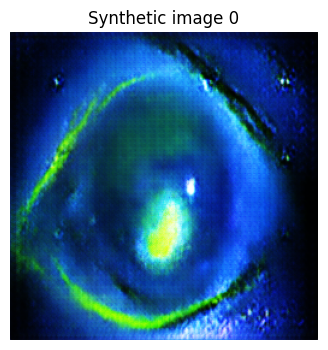

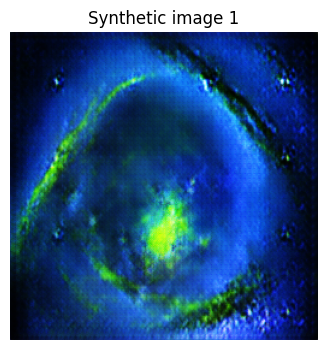

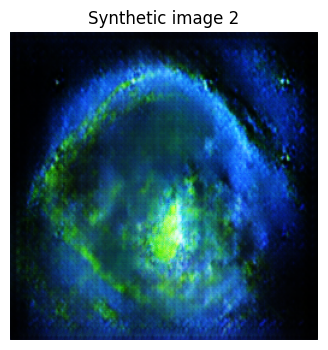

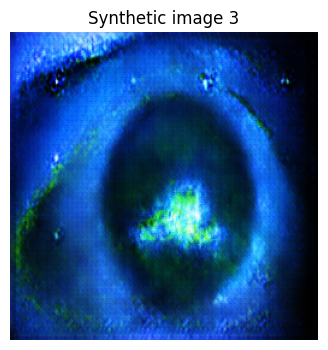

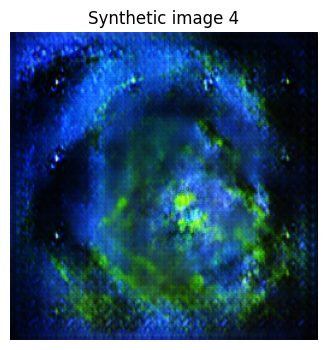

In [31]:
import matplotlib.pyplot as plt
import os

#visualizing a few pairs
num_to_show = 5
for i in range(num_to_show):
    img_path = os.path.join(SYNTH_IMAGES_DIR, f"synthetic_{i}.png")
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    plt.figure(figsize=(4,4))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"Synthetic image {i}")
    plt.show()

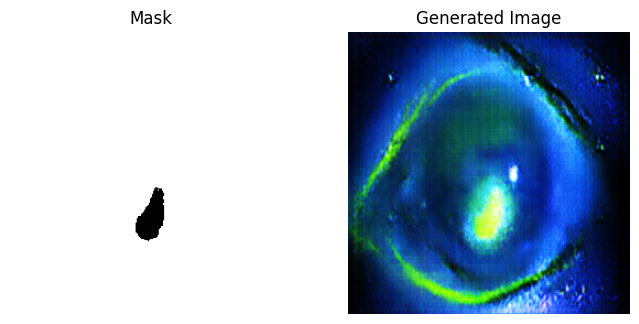

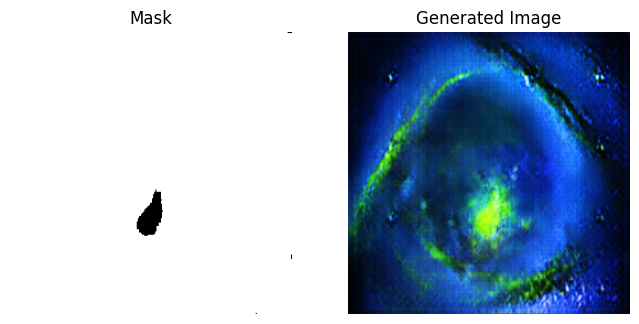

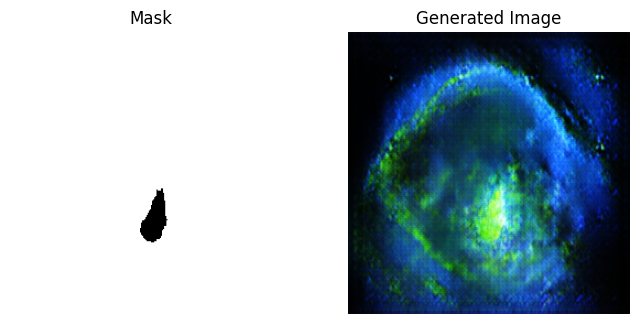

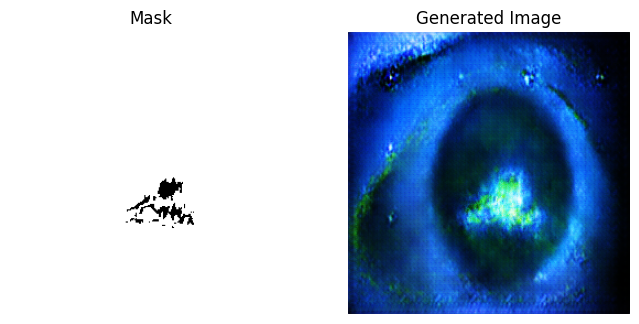

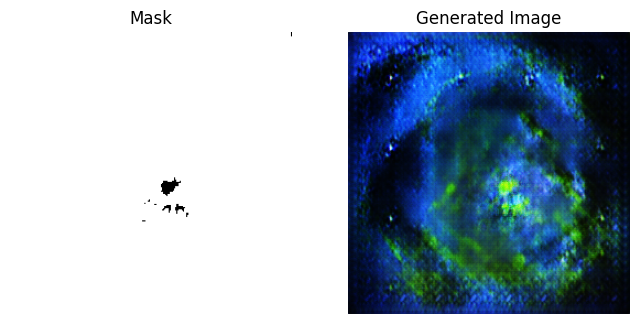

In [32]:
import matplotlib.pyplot as plt

for i in range(5):  # show first 5
    mask = perturbed_masks[i, :, :, 0]  # original mask
    img = cv2.imread(os.path.join(SYNTH_IMAGES_DIR, f"synthetic_{i}.png"))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(img_rgb)
    plt.title("Generated Image")
    plt.axis('off')

    plt.show()


# Conclusion

1.   Result not too relistic
2.   Strong GAN artefacts :
Grainy noise
High frequency speckling and
Repeating patterns across samples

1. Some generated ulcers extend outside the mask region


Therefore If I  train UNet on these pairs:
The model may learn:
1.   ulcer = neon green noise
2.   ulcer has GAN texture


Instead of:

1.  real ulcer boundaries
2.  real corneal opacity patterns





